In [1]:
print("Ambiente configurado com sucesso!")



Ambiente configurado com sucesso!


In [3]:
%pip install pandas
import pandas as pd
dados = pd.read_csv("data/titanic.csv")
display(dados.head())

Note: you may need to restart the kernel to use updated packages.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
dados.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


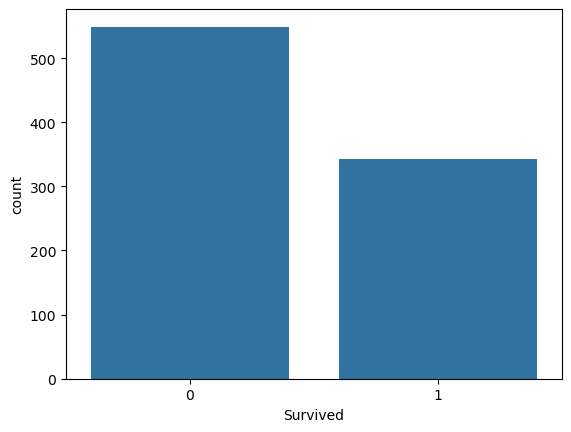

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=dados, x='Survived')
plt.show()

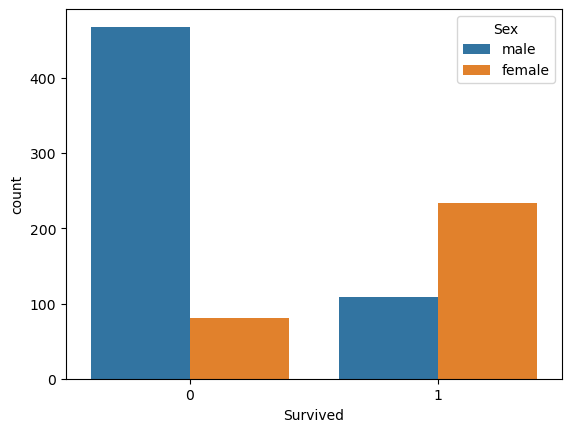

In [9]:
sns.countplot(data=dados, x='Survived', hue='Sex')
plt.show()

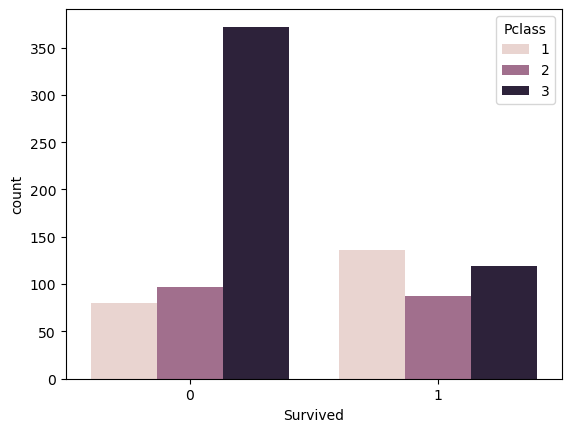

In [10]:
sns.countplot(data=dados, x='Survived', hue='Pclass')
plt.show()

In [11]:
# 1. Ver quantos passageiros estão sem idade preenchida
nulos_antes = dados['Age'].isnull().sum()
print(f"Idades faltando antes: {nulos_antes}")

# 2. Preencher os buracos com a mediana das idades
mediana_idade = dados['Age'].median()
dados['Age'] = dados['Age'].fillna(mediana_idade)

# 3. Conferir se resolveu o problema
nulos_depois = dados['Age'].isnull().sum()
print(f"Idades faltando depois: {nulos_depois}")

Idades faltando antes: 177
Idades faltando depois: 0


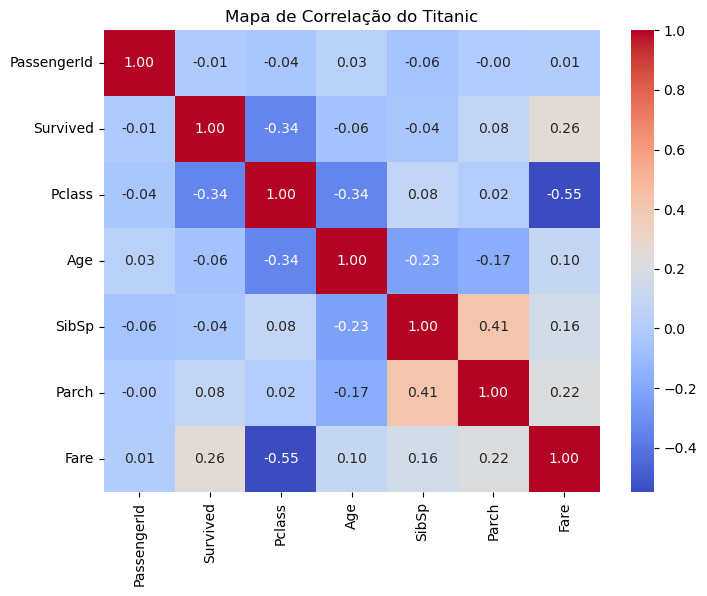

In [12]:
# Selecionar apenas as colunas com números (o mapa de calor precisa de números para calcular)
colunas_numericas = dados.select_dtypes(include=['number'])

# Calcular a correlação e desenhar o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(colunas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlação do Titanic')
plt.show()